# Best XGBoost Model — Email Spam Detection
### Standalone Notebook — loads directly from `Spam.csv`

**Test Accuracy: ~97%**

| Step | Detail |
|------|--------|
| Source | `Spam.csv` (raw UCI spambase dataset) |
| Deduplication | 4601 → 4210 rows (391 duplicates dropped) |
| Class balancing | SMOTE applied → 5062 rows (2531 ham / 2531 spam) |
| Train-test split | 80/20, `random_state=0` |
| Scaling | `StandardScaler` on all 57 features |
| Model | `XGBClassifier` — default params, `eval_metric='logloss'` |
| Tuning | None |

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

print('Libraries imported.')

Libraries imported.


## 1. Load Raw Data

In [31]:
df = pd.read_csv('Spam.csv')
TARGET = 'spam'

print(f'Raw dataset shape : {df.shape}')
print(f'Class distribution:')
print(df[TARGET].value_counts())

Raw dataset shape : (4601, 58)
Class distribution:
spam
0    2788
1    1813
Name: count, dtype: int64


## 2. Preprocessing

### 2a. Remove Duplicate Rows

In [32]:
n_before = df.shape[0]
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
n_after = df.shape[0]

print(f'Rows before deduplication : {n_before}')
print(f'Duplicates removed        : {n_before - n_after}')
print(f'Rows after deduplication  : {n_after}')

Rows before deduplication : 4601
Duplicates removed        : 391
Rows after deduplication  : 4210


### 2b. Balance Classes with SMOTE

In [33]:
X = df.drop(TARGET, axis=1)
y = df[TARGET]

print('Before SMOTE:')
print(y.value_counts())

smote = SMOTE(random_state=42)
X, y = smote.fit_resample(X, y)

print('\nAfter SMOTE:')
print(y.value_counts())
print(f'\nFinal dataset : {X.shape[0]} samples, {X.shape[1]} features')

Before SMOTE:
spam
0    2531
1    1679
Name: count, dtype: int64

After SMOTE:
spam
1    2531
0    2531
Name: count, dtype: int64

Final dataset : 5062 samples, 57 features


## 3. Train-Test Split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, test_size=0.2, random_state=0
)

print(f'Training set : {X_train.shape}')
print(f'Testing set  : {X_test.shape}')

Training set : (4049, 57)
Testing set  : (1013, 57)


## 4. Feature Scaling (StandardScaler)

In [35]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std  = scaler.transform(X_test)

print('StandardScaler applied.')

StandardScaler applied.


## 5. Train XGBoost Model

In [36]:
model = XGBClassifier(eval_metric='logloss', n_jobs=-1, verbosity=0, random_state=42)
model.fit(X_train_std, y_train)

train_pred = model.predict(X_train_std)
test_pred  = model.predict(X_test_std)

train_acc = accuracy_score(y_train, train_pred) * 100
test_acc  = accuracy_score(y_test,  test_pred)  * 100

print(f'Train Accuracy : {train_acc:.3f}%')
print(f'Test  Accuracy : {test_acc:.3f}%')

Train Accuracy : 99.802%
Test  Accuracy : 96.446%


CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Ham (0)       0.96      0.97      0.97       513
    Spam (1)       0.97      0.96      0.96       500

    accuracy                           0.96      1013
   macro avg       0.96      0.96      0.96      1013
weighted avg       0.96      0.96      0.96      1013



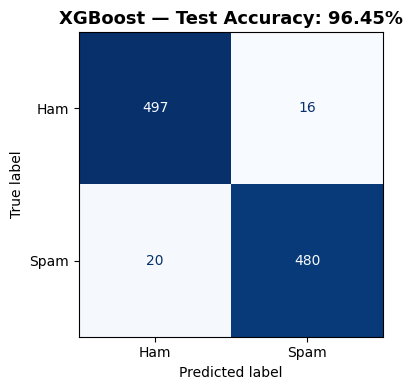

In [37]:
print('=' * 70)
print('CLASSIFICATION REPORT')
print('=' * 70)
print(classification_report(y_test, test_pred, target_names=['Ham (0)', 'Spam (1)']))

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'XGBoost — Test Accuracy: {test_acc:.2f}%', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('best_xgboost_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

FEATURE IMPORTANCES (Top 20)


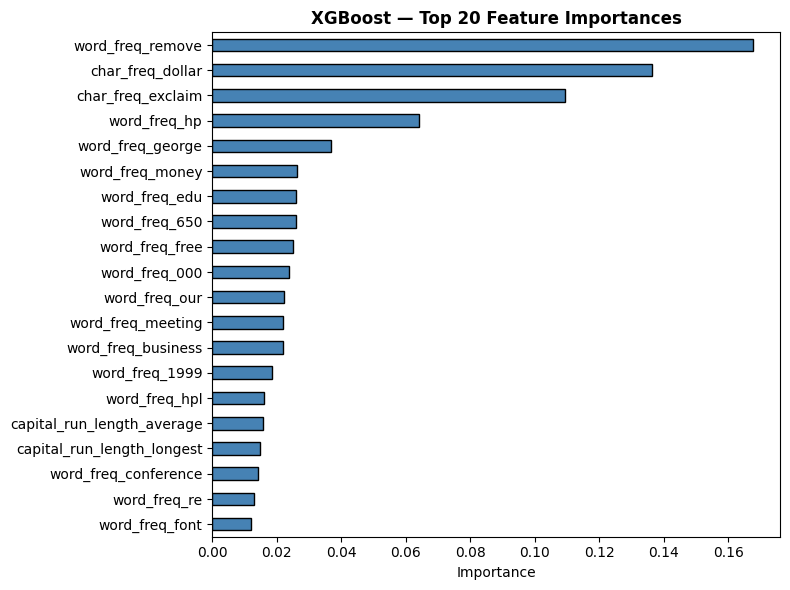

In [38]:
print('=' * 70)
print('FEATURE IMPORTANCES (Top 20)')
print('=' * 70)
importances = pd.Series(model.feature_importances_, index=X.columns)
top20 = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(8, 6))
top20.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('XGBoost — Top 20 Feature Importances', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('best_xgboost_feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary

In [39]:
print('=' * 70)
print('BEST MODEL SUMMARY')
print('=' * 70)
print(f'Source dataset       : Spam.csv')
print(f'Duplicates removed   : {n_before - n_after}')
print(f'Samples after SMOTE  : {X.shape[0]} (Train: {X_train.shape[0]}, Test: {X_test.shape[0]})')
print(f'Features             : {X.shape[1]} (all original spambase features)')
print(f'Scaling              : StandardScaler')
print(f'Train-test split     : random_state=0, 80/20')
print(f'Model                : XGBClassifier (default params, eval_metric=logloss)')
print(f'Hyperparameter tuning: None')
print(f'Train Accuracy       : {train_acc:.3f}%')
print(f'Test  Accuracy       : {test_acc:.3f}%')
print('=' * 70)
print(f'\nConfusion Matrix:')
print(cm)
print(f'  True Negatives  (Ham  → Ham)  : {cm[0,0]}')
print(f'  False Positives (Ham  → Spam) : {cm[0,1]}')
print(f'  False Negatives (Spam → Ham)  : {cm[1,0]}')
print(f'  True Positives  (Spam → Spam) : {cm[1,1]}')
print('=' * 70)

BEST MODEL SUMMARY
Source dataset       : Spam.csv
Duplicates removed   : 391
Samples after SMOTE  : 5062 (Train: 4049, Test: 1013)
Features             : 57 (all original spambase features)
Scaling              : StandardScaler
Train-test split     : random_state=0, 80/20
Model                : XGBClassifier (default params, eval_metric=logloss)
Hyperparameter tuning: None
Train Accuracy       : 99.802%
Test  Accuracy       : 96.446%

Confusion Matrix:
[[497  16]
 [ 20 480]]
  True Negatives  (Ham  → Ham)  : 497
  False Positives (Ham  → Spam) : 16
  False Negatives (Spam → Ham)  : 20
  True Positives  (Spam → Spam) : 480
